In [17]:
#testing the ODEsolving etc.

In [22]:
import scipy
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd
from matplotlib import pyplot as plt

In [23]:
all_df = pd.read_csv('GSE124821_data.csv')
print(all_df)

     Unnamed: 0  Dendritic_quanTIseq  NK_quanTIseq  T.CD8_quanTIseq  \
0    SRX5100689             0.020644      0.007343         0.003824   
1    SRX5100686             0.030451      0.010853         0.000000   
2    SRX5100687             0.030096      0.010989         0.000349   
3    SRX5100692             0.030466      0.010471         0.000333   
4    SRX5100693             0.031649      0.008606         0.000000   
..          ...                  ...           ...              ...   
187  SRX5100807             0.032076      0.012687         0.000000   
188  SRX5100814             0.027448      0.011238         0.000000   
189  SRX5100813             0.021779      0.009103         0.000000   
190  SRX5100812             0.029557      0.013101         0.000407   
191  SRX5100684             0.021779      0.009573         0.000214   

     Tregs_quanTIseq      Mouse_treatment Condition Timepoint      GSM_ID  \
0           0.005128  antiPD1; antiCTLA4;      day7      day7  GSM3554


Number of replicates 5
Dendritic_quanTIseq    0.030802
NK_quanTIseq           0.007164
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.003942
dtype: float64
<class 'pandas.Series'>

Number of replicates 4
Dendritic_quanTIseq    0.030666
NK_quanTIseq           0.010230
T.CD8_quanTIseq        0.000171
Tregs_quanTIseq        0.003666
dtype: float64
<class 'pandas.Series'>

Number of replicates 6
Dendritic_quanTIseq    0.024924
NK_quanTIseq           0.006209
T.CD8_quanTIseq        0.000000
Tregs_quanTIseq        0.002772
dtype: float64
<class 'pandas.Series'>


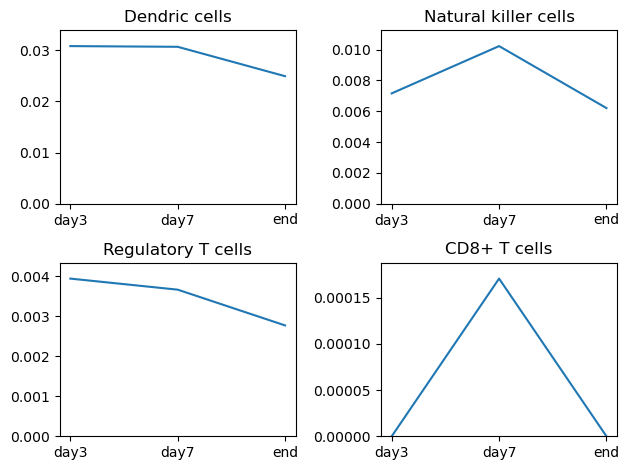

In [27]:
KPB25L_df = all_df[all_df['Cell_Line']=="KPB25L"]
no_treatment_KPB25L_df = KPB25L_df[KPB25L_df['Mouse_treatment']=="no_treatment"]
quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]
Ds = []
NKs = []
T8s = []
Tregs = []

for day in ["day3","day7","end"]:
    day_df = no_treatment_KPB25L_df[no_treatment_KPB25L_df['Condition'] == day]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    Ds.append(averages["Dendritic_quanTIseq"])
    NKs.append(averages["NK_quanTIseq"])
    T8s.append(averages["T.CD8_quanTIseq"])
    Tregs.append(averages["Tregs_quanTIseq"])

time_points = ["day3","day7","end"]

fig,ax = plt.subplots(2,2)

Dplot = ax[0,0]
Dplot.plot(time_points,Ds)
Dplot.set_title('Dendric cells')
Dplot.set_ylim(0.0,max(Ds)*1.1)
NKplot = ax[0,1]
NKplot.plot(time_points,NKs)
NKplot.set_title('Natural killer cells')
NKplot.set_ylim(0.0,max(NKs)*1.1)

Tregplot = ax[1,0]
Tregplot.plot(time_points,Tregs)
Tregplot.set_title('Regulatory T cells')
Tregplot.set_ylim(0.0,max(Tregs)*1.1)

T8plot = ax[1,1]
T8plot.plot(time_points,T8s)
T8plot.set_title('CD8+ T cells')
T8plot.set_ylim(0.0,max(T8s)*1.1)

plt.tight_layout()
plt.show()

In [29]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC*D_0*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr*Tr_0*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8 * T8_0*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
eta_N = 300
eta_8 = 328.2/4
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)


In [30]:
C0 = [0.4,4e-4,3e-4,5e-4,1.5e-3]
C0 = [0.8,0.025,0.0055,0.00,0.0029]

tspan = (0.0,50.0,)

In [31]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

In [32]:
from matplotlib import pyplot as plt

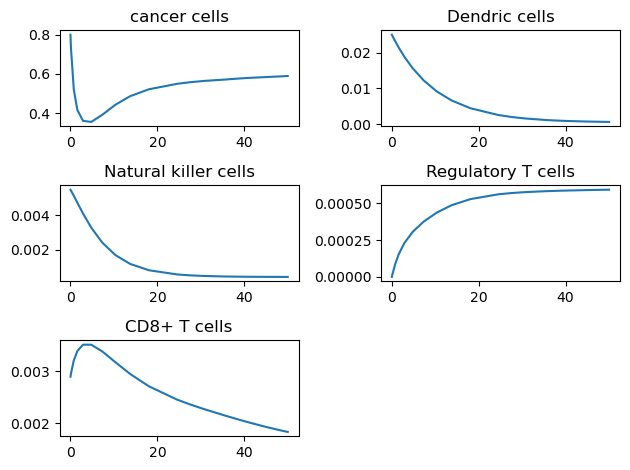

In [33]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)

In [ ]:
param_grid = {
    'sigma_N':[5e-3]
    'lambda_Tr':[
}

In [8]:
# parameters we are varying
for param in param_grid:
    sigma_N,lambda_Tr,Tr_0,lambda_T8,T8_0,K_D,K_Tr=parm0 
    def cancer_ode_parametrised(t,y):
        return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
                   D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
                   beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
                  T8_0,K_D,K_Tr)
    tspan = (0.0,200.0,)
    sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

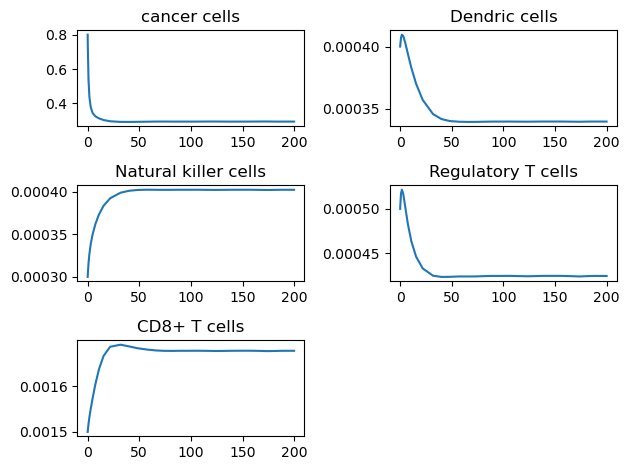

In [9]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [94]:
# SDEs
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))

In [95]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

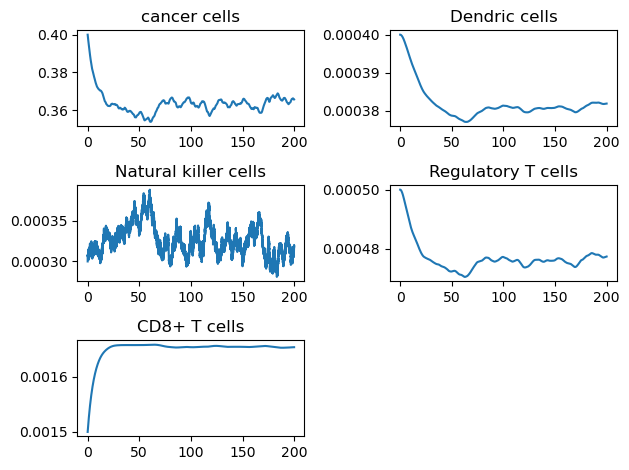

In [96]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendric cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()
